In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Indian_Kids_Screen_Time.csv")

In [3]:
df.head()

,Age,Gender,Avg_Daily_Screen_Time_hr,Primary_Device,Exceeded_Recommended_Limit,Educational_to_Recreational_Ratio,Health_Impacts,Urban_or_Rural
0,14,Male,3.99,Smartphone,True,0.42,"Poor Sleep, Eye Strain",Urban
1,11,Female,4.61,Laptop,True,0.30,Poor Sleep,Urban
2,18,Female,3.73,TV,True,0.32,Poor Sleep,Urban
3,15,Female,1.21,Laptop,False,0.39,NaN,Urban
4,12,Female,5.89,Smartphone,True,0.49,"Poor Sleep, Anxiety",Urban


In [4]:
print("Dataset Shape:", df.shape)

Dataset Shape: (9712, 8)


In [5]:
print("Columns:", df.columns)

Columns: Index(['Age', 'Gender', 'Avg_Daily_Screen_Time_hr', 'Primary_Device',
       'Exceeded_Recommended_Limit', 'Educational_to_Recreational_Ratio',
       'Health_Impacts', 'Urban_or_Rural'],
      dtype='object')


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9712 entries, 0 to 9711
Data columns (total 8 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                9712 non-null   int64  
 1   Gender                             9712 non-null   object 
 2   Avg_Daily_Screen_Time_hr           9712 non-null   float64
 3   Primary_Device                     9712 non-null   object 
 4   Exceeded_Recommended_Limit         9712 non-null   bool   
 5   Educational_to_Recreational_Ratio  9712 non-null   float64
 6   Health_Impacts                     6494 non-null   object 
 7   Urban_or_Rural                     9712 non-null   object 
dtypes: bool(1), float64(2), int64(1), object(4)
memory usage: 540.7+ KB


In [7]:
df.describe()

,Age,Avg_Daily_Screen_Time_hr,Educational_to_Recreational_Ratio
count,9712.000000,9712.000000,9712.000000
mean,12.979201,4.352837,0.427226
std,3.162437,1.718232,0.073221
min,8.000000,0.000000,0.300000
25%,10.000000,3.410000,0.370000
50%,13.000000,4.440000,0.430000
75%,16.000000,5.380000,0.480000
max,18.000000,13.890000,0.600000


In [8]:
df.isnull().sum()

Age                                     0
Gender                                  0
Avg_Daily_Screen_Time_hr                0
Primary_Device                          0
Exceeded_Recommended_Limit              0
Educational_to_Recreational_Ratio       0
Health_Impacts                       3218
Urban_or_Rural                          0
dtype: int64

In [9]:
df['Health_Impacts'] = df['Health_Impacts'].fillna("None")

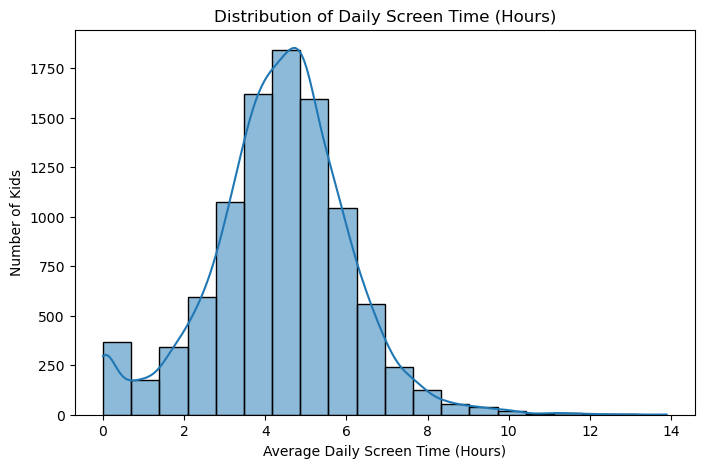

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(df['Avg_Daily_Screen_Time_hr'], bins=20, kde=True)
plt.title("Distribution of Daily Screen Time (Hours)")
plt.xlabel("Average Daily Screen Time (Hours)")
plt.ylabel("Number of Kids")
plt.show()

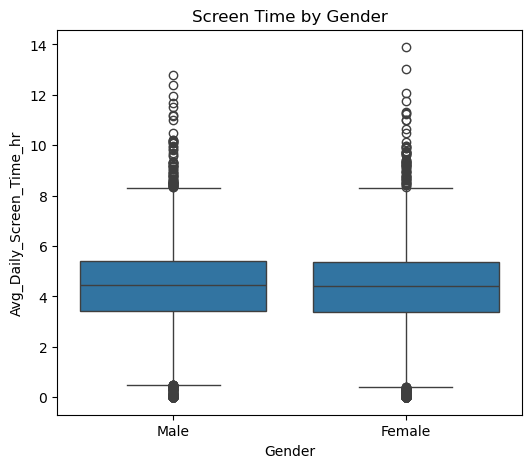

In [11]:
plt.figure(figsize=(6,5))
sns.boxplot(x='Gender', y='Avg_Daily_Screen_Time_hr', data=df)
plt.title("Screen Time by Gender")
plt.show()

In [12]:
df['Age_Group'] = pd.cut(df['Age'],
                         bins=[5,10,13,16,18],
                         labels=['6-10','11-13','14-16','17-18'])

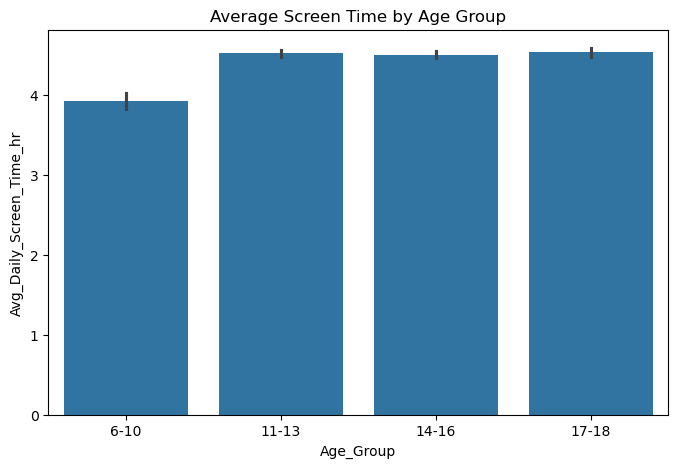

In [13]:
plt.figure(figsize=(8,5))
sns.barplot(x='Age_Group', y='Avg_Daily_Screen_Time_hr', data=df)
plt.title("Average Screen Time by Age Group")
plt.show()

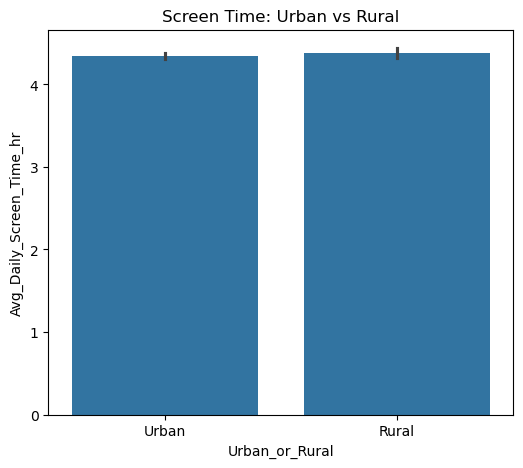

In [14]:
plt.figure(figsize=(6,5))
sns.barplot(x='Urban_or_Rural', y='Avg_Daily_Screen_Time_hr', data=df)
plt.title("Screen Time: Urban vs Rural")
plt.show()

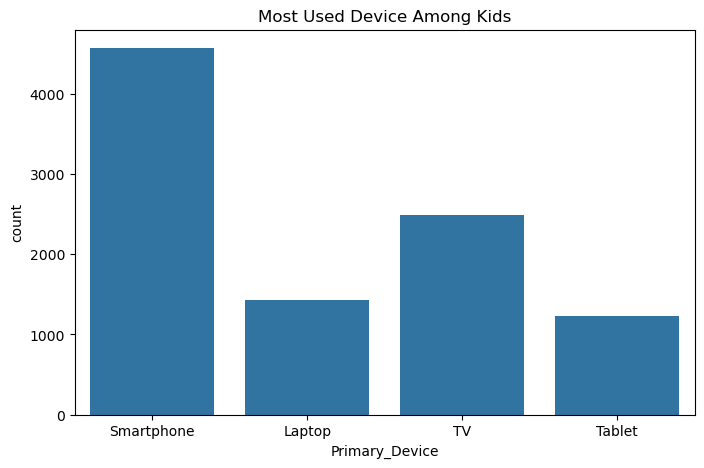

In [15]:
plt.figure(figsize=(8,5))
sns.countplot(x='Primary_Device', data=df)
plt.title("Most Used Device Among Kids")
plt.show()

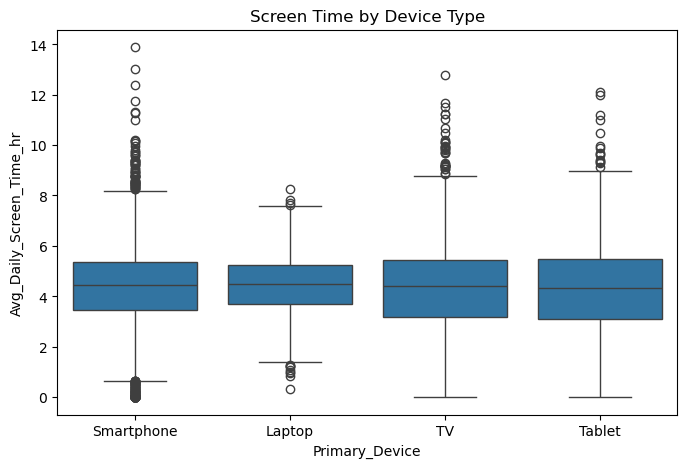

In [16]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Primary_Device', y='Avg_Daily_Screen_Time_hr', data=df)
plt.title("Screen Time by Device Type")
plt.show()

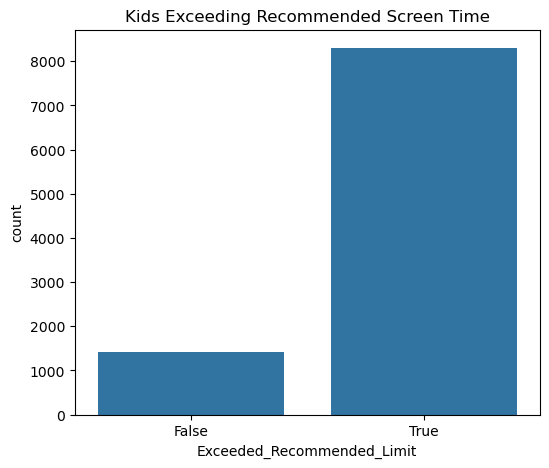

In [17]:
plt.figure(figsize=(6,5))
sns.countplot(x='Exceeded_Recommended_Limit', data=df)
plt.title("Kids Exceeding Recommended Screen Time")
plt.show()

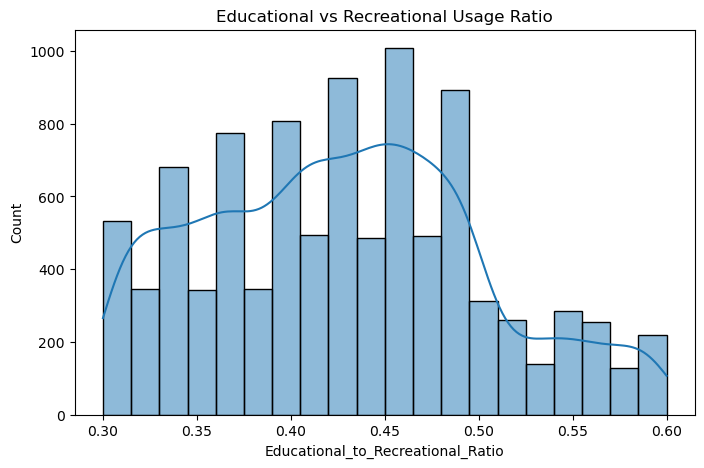

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(df['Educational_to_Recreational_Ratio'], bins=20, kde=True)
plt.title("Educational vs Recreational Usage Ratio")
plt.show()

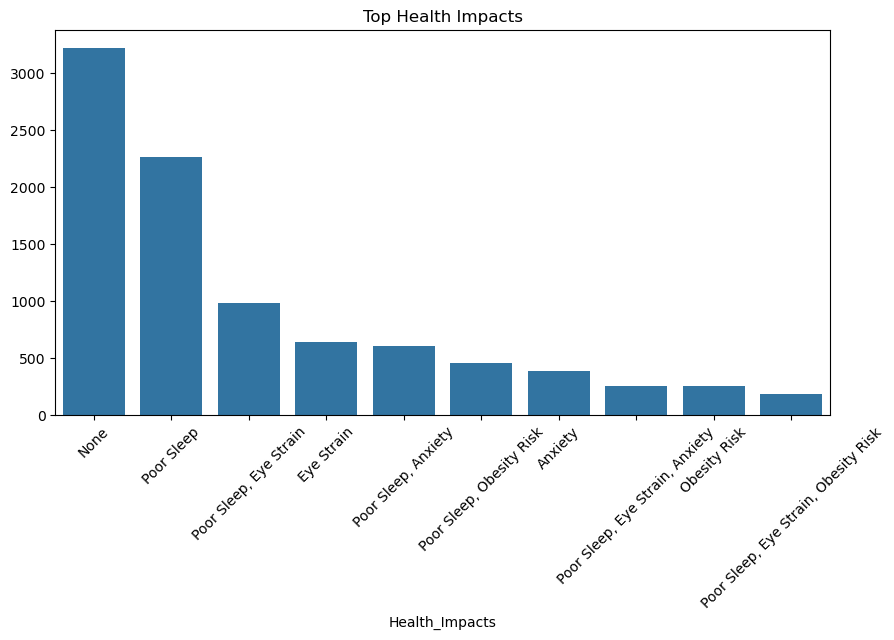

In [19]:
health_counts = df['Health_Impacts'].value_counts().head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=health_counts.index, y=health_counts.values)
plt.xticks(rotation=45)
plt.title("Top Health Impacts")
plt.show()

In [21]:
# Create Age Bands
df['Age_Band'] = pd.cut(
    df['Age'],
    bins=[5,10,13,16,18],
    labels=['6-10','11-13','14-16','17-18']
)

df[['Age','Age_Band']].head()

,Age,Age_Band
0,14,14-16
1,11,11-13
2,18,17-18
3,15,14-16
4,12,11-13


In [27]:
# Create Screen Time Category
df['Screen_Time_Category'] = pd.cut(
    df['Avg_Daily_Screen_Time_hr'],
    bins=[0,2,4,10],
    labels=['Low (0-2h)','Moderate (2-4h)','High (4h+)']
)
df[['Avg_Daily_Screen_Time_hr','Screen_Time_Category']].head()

,Avg_Daily_Screen_Time_hr,Screen_Time_Category
0,3.99,Moderate (2-4h)
1,4.61,High (4h+)
2,3.73,Moderate (2-4h)
3,1.21,Low (0-2h)
4,5.89,High (4h+)


In [26]:
# Create Activity Dominance Column
df['Activity_Dominance'] = df['Educational_to_Recreational_Ratio'].apply(
    lambda x: 'Educational' if x > 1 else 'Recreational'
)
df[['Educational_to_Recreational_Ratio','Activity_Dominance']].head()

,Educational_to_Recreational_Ratio,Activity_Dominance
0,0.42,Recreational
1,0.30,Recreational
2,0.32,Recreational
3,0.39,Recreational
4,0.49,Recreational


In [25]:
# Calculate Device Share
device_share = df['Primary_Device'].value_counts(normalize=True) * 100
device_share = device_share.reset_index()
device_share.columns = ['Primary_Device','Device_Share_Percentage']
device_share

,Primary_Device,Device_Share_Percentage
0,Smartphone,47.034596
1,TV,25.607496
2,Laptop,14.754942
3,Tablet,12.602965


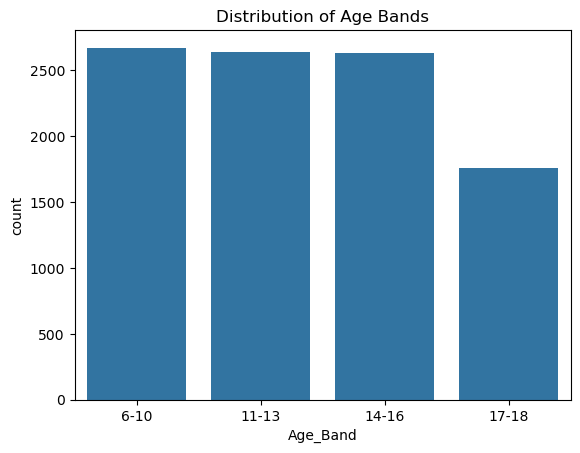

In [29]:
sns.countplot(x='Age_Band', data=df)
plt.title("Distribution of Age Bands")
plt.show()

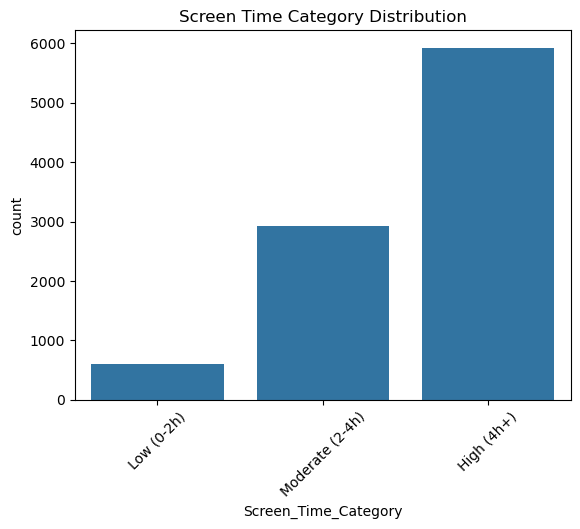

In [30]:
sns.countplot(x='Screen_Time_Category', data=df)
plt.title("Screen Time Category Distribution")
plt.xticks(rotation=45)
plt.show()

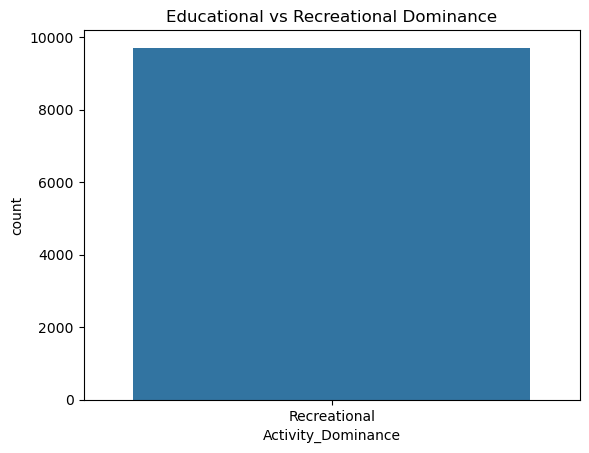

In [31]:
sns.countplot(x='Activity_Dominance', data=df)
plt.title("Educational vs Recreational Dominance")
plt.show()